# This notebook fit a GEV to maximum annual percipitation using MLE and bayesian methods
##### Author: Omid Emamjomehzadeh (https://www.omidemam.com/)
##### Supervisor: Dr. Omar Wani (https://engineering.nyu.edu/faculty/omar-wani)
##### Hydrologic Systems Group @NYU (https://www.omarwani.com/)

In [ ]:
#import libraries
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib as mpl
from matplotlib.animation import FuncAnimation, PillowWriter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.colors import LinearSegmentedColormap
import xarray as xr
import pandas as pd
import numpy as np
import pymc3 as pm3
import scipy.stats as stats
from scipy import stats
from scipy.stats import genextreme
from scipy.stats import truncnorm
from scipy.stats import norm
from scipy.optimize import minimize
import seaborn as sns
import arviz as az
import pymc3 as pm
import os
import theano.tensor as tt
from theano.compile.ops import as_op
import theano
from pymc3.distributions.dist_math import bound
from scipy.stats import genextreme
import warnings
from arviz.plots import plot_utils as azpu
import arviz as az
from tqdm import tqdm
%matplotlib inline
sns.set()
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore', UserWarning)
theano.config.warn.round=False
from watermark import watermark
from datetime import datetime
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from matplotlib.collections import LineCollection
plt.style.use('default')


# Read AORC data

In [3]:
# --- Paths ---
BASE_DIR = r"D:\BMM-IDF4Drainage_data_results\Data\AORC"
CITIES_CSV = r"D:\BMM-IDF4Drainage_data_results\us_cities_coordinates.csv"

# --- Load city list ---
cities_df = pd.read_csv(CITIES_CSV)
city_names = cities_df["City"].astype(str).str.strip().tolist()

# --- Final container ---
dataframes = {}

# --- Helper to read a CSV safely ---
def read_if_exists(path, usecols=None):
    if os.path.exists(path):
        return pd.read_csv(path, usecols=usecols)
    return None

# --- Build combined structure ---
for city_full in city_names:
    # Strip the state to get short name
    city_short = city_full.split(",")[0].strip()

    # Paths to the hourly and daily data
    hourly_path = os.path.join(BASE_DIR, city_full, f"{city_full}_annual_max_hourly.csv")
    daily_path  = os.path.join(BASE_DIR, city_full, f"{city_full}_annual_max_daily.csv")

    df_hourly = read_if_exists(hourly_path, usecols=["year", "max_hourly_mm"])
    df_daily  = read_if_exists(daily_path,  usecols=["year", "max_daily_mm"])

    if df_hourly is not None and df_daily is not None:
        # Keep only the common years between both
        df = pd.merge(df_hourly, df_daily, on="year", how="inner")

        # Rename columns to match your original structure
        df.rename(columns={"max_hourly_mm": "1h", "max_daily_mm": "24h"}, inplace=True)

        # Filter to 1979–2024 (if desired)
        df = df[df["year"].between(1979, 2024)]

        # Sort by year and reset index
        df = df.sort_values("year").reset_index(drop=True)

        # Save to dict with short name
        dataframes[city_short] = df

# --- print ---
print(dataframes["Birmingham"].head())
print(dataframes["Phoenix"])
print(list(dataframes.keys()))
# cities names
cities = ['Birmingham', 'Phoenix', 'Little Rock', 'Los Angeles', 'Denver', 'Hartford', 'Wilmington', 'Miami', 'Atlanta', 'Boise',
           'Chicago', 'Indianapolis', 'Des Moines', 'Wichita', 'Louisville', 'New Orleans', 'Portland', 'Baltimore', 'Boston', 'Detroit',
             'Minneapolis', 'Jackson', 'St. Louis', 'Billings', 'Omaha', 'Las Vegas', 'Manchester', 'Newark', 'Albuquerque', 'New York City',
               'Charlotte', 'Fargo', 'Columbus', 'Oklahoma City', 'Philadelphia', 'Providence', 'Charleston', 'Sioux Falls', 'Nashville', 'Houston',
                 'Salt Lake City', 'Burlington', 'Richmond', 'Seattle', 'Milwaukee', 'Cheyenne']             



   year         1h         24h
0  1979  21.200000  135.500002
1  1980  18.300000  102.500002
2  1981  43.200001   77.800001
3  1982  35.500001   74.100001
4  1983  24.100000  103.300002
    year         1h        24h
0   1979   8.400000  31.300000
1   1980   3.500000  14.100000
2   1981   4.600000  22.600000
3   1982   6.800000  24.700000
4   1983   9.700000  40.700001
5   1984   8.400000  32.300000
6   1985  10.400000  27.200000
7   1986   5.700000  28.900000
8   1987  15.000000  34.300001
9   1988   4.700000  26.100000
10  1989  20.400000  29.400000
11  1990   7.900000  29.400000
12  1991  20.200000  25.200000
13  1992  13.500000  42.400001
14  1993   7.700000  35.000001
15  1994  10.800000  15.300000
16  1995   6.800000  21.200000
17  1996   5.900000  11.300000
18  1997  11.300000  17.600000
19  1998   9.500000  18.200000
20  1999  11.900000  26.600000
21  2000   8.300000  51.100001
22  2001   6.000000  16.800000
23  2002   7.200000  13.700000
24  2003  16.100000  32.700000
25  2004

In [9]:
# Save
combined_df = pd.concat(
    [df.assign(City=city) for city, df in dataframes.items()],
    ignore_index=True
)

combined_path = r"D:\BMM-IDF4Drainage_data_results\Data\AORC\AORC_hourly_daily_all.csv"
combined_df.to_csv(combined_path, index=False)

# Read CMIP6 data (2015-2100)

In [2]:
# --- Paths ---
BASE_DIR = r"D:\BMM-IDF4Drainage_data_results\Data\CMIP6"
CITIES_CSV = r"D:\BMM-IDF4Drainage_data_results\us_cities_coordinates.csv"

# --- Load city list ---
cities_df = pd.read_csv(CITIES_CSV)
city_names = cities_df["City"].astype(str).str.strip().tolist()

# --- Final container ---
dataframes_ssp = {}

# --- Helper to read a CSV safely ---
def read_if_exists(path, usecols=None):
    if os.path.exists(path):
        return pd.read_csv(path, usecols=usecols)
    return None

# --- Build combined structure ---
for city_full in city_names:
    # Strip the state to get short name
    city_short = city_full.split(",")[0].strip()

    # Paths to the hourly and daily data
    daily_path_126  = os.path.join(BASE_DIR, city_full, f"{city_full}_SSP126_yearly_max.csv")
    daily_path_370  = os.path.join(BASE_DIR, city_full, f"{city_full}_SSP370_yearly_max.csv")
    daily_path_585  = os.path.join(BASE_DIR, city_full, f"{city_full}_SSP585_yearly_max.csv")


    df_daily_126  = read_if_exists(daily_path_126,  usecols=["year", "max_daily_mm"])
    df_daily_370  = read_if_exists(daily_path_370,  usecols=["year", "max_daily_mm"])
    df_daily_585  = read_if_exists(daily_path_585,  usecols=["year", "max_daily_mm"])

    if (df_daily_126 is not None) and (df_daily_370 is not None) and (df_daily_585 is not None):

        # rename columns so they don't collide, then merge pairwise
        df_daily_126 = df_daily_126.rename(columns={"max_daily_mm": "126"})
        df_daily_370 = df_daily_370.rename(columns={"max_daily_mm": "370"})
        df_daily_585 = df_daily_585.rename(columns={"max_daily_mm": "585"})

        # Merge two at a time
        df = df_daily_126.merge(df_daily_370, on="year", how="inner").merge(df_daily_585, on="year", how="inner")

        # Optional filter range (CMIP6 futures typically 2015–2100)
        df = df[df["year"].between(2015, 2100)]

        df = df.sort_values("year").reset_index(drop=True)
        # --- Split each scenario into two new columns ---
        df["126_2025_2100"] = np.where(df["year"].between(2025, 2100), df["126"], np.nan)
        df["126_2025_2064"] = np.where(df["year"].between(2025, 2064), df["126"], np.nan)
        df["126_2065_2100"] = np.where(df["year"].between(2065, 2100), df["126"], np.nan)

        df["370_2025_2100"] = np.where(df["year"].between(2025, 2100), df["370"], np.nan)
        df["370_2025_2064"] = np.where(df["year"].between(2025, 2064), df["370"], np.nan)
        df["370_2065_2100"] = np.where(df["year"].between(2065, 2100), df["370"], np.nan)

        df["585_2025_2100"] = np.where(df["year"].between(2025, 2100), df["585"], np.nan)
        df["585_2025_2064"] = np.where(df["year"].between(2025, 2064), df["585"], np.nan)
        df["585_2065_2100"] = np.where(df["year"].between(2065, 2100), df["585"], np.nan)
        df["585_2075_2100"] = np.where(df["year"].between(2075, 2100), df["585"], np.nan)

        dataframes_ssp[city_short] = df

# --- print ---
print(dataframes_ssp["Birmingham"].head())
print(dataframes_ssp["Phoenix"])
print(list(dataframes_ssp.keys()))
# cities names
cities = ['Birmingham', 'Phoenix', 'Little Rock', 'Los Angeles', 'Denver', 'Hartford', 'Wilmington', 'Miami', 'Atlanta', 'Boise',
           'Chicago', 'Indianapolis', 'Des Moines', 'Wichita', 'Louisville', 'New Orleans', 'Portland', 'Baltimore', 'Boston', 'Detroit',
             'Minneapolis', 'Jackson', 'St. Louis', 'Billings', 'Omaha', 'Las Vegas', 'Manchester', 'Newark', 'Albuquerque', 'New York City',
               'Charlotte', 'Fargo', 'Columbus', 'Oklahoma City', 'Philadelphia', 'Providence', 'Charleston', 'Sioux Falls', 'Nashville', 'Houston',
                 'Salt Lake City', 'Burlington', 'Richmond', 'Seattle', 'Milwaukee', 'Cheyenne']             



   year        126         370        585  126_2025_2100  126_2025_2064  \
0  2015  62.940857  114.352142  92.040123            NaN            NaN   
1  2016  81.798233   61.884373  62.521687            NaN            NaN   
2  2017  44.011440   66.001343  58.154327            NaN            NaN   
3  2018  45.637985   64.430138  86.788147            NaN            NaN   
4  2019  77.624031   63.680565  60.768650            NaN            NaN   

   126_2065_2100  370_2025_2100  370_2025_2064  370_2065_2100  585_2025_2100  \
0            NaN            NaN            NaN            NaN            NaN   
1            NaN            NaN            NaN            NaN            NaN   
2            NaN            NaN            NaN            NaN            NaN   
3            NaN            NaN            NaN            NaN            NaN   
4            NaN            NaN            NaN            NaN            NaN   

   585_2025_2064  585_2065_2100  585_2075_2100  
0            NaN   

### Likelihood of the Generalized Extreme Value (GEV) Distribution

For a random variable  
$$
X \sim \text{GEV}(\mu, \sigma, \xi),
$$

where:
- $\mu \in \mathbb{R}$, (location);
- $\sigma > 0$, (scale);
- $\xi \in \mathbb{R}$, (shape).

the likelihood function differs depending on whether the shape parameter ($\xi$)

---

#### **Case 1: ξ ≠ 0**

$$
f(x \mid \mu, \sigma, \xi)
= \frac{1}{\sigma}
\left( 1 + \xi \frac{x - \mu}{\sigma} \right)^{-\frac{1}{\xi} - 1}
\exp\!\left[
  \left( 1 + \xi \frac{x - \mu}{\sigma} \right)^{\frac{1}{\xi}}
\right],
$$

---

#### **Case 2: ξ = 0** (Gumbel limit)

$$
f(x \mid \mu, \sigma)
= \frac{1}{\sigma}\,
\exp\!\left(-\frac{x-\mu}{\sigma}\right)^{\xi+1}\,
\exp\!\left\{-\exp\!\left(-\frac{x-\mu}{\sigma}\right)\right\}
$$

---

#### **Log-Likelihood implementation**

For independent observations  
$$
x_1, x_2, \ldots, x_n:
$$

$$
\log \mathcal{L}(\mu, \sigma, \xi)
= \sum_{i=1}^{n} \log f(x_i \mid \mu, \sigma, \xi)
$$

**If ξ >0.0001**:
$$
\log \mathcal{L}(\mu,\sigma,\xi)
= \sum
\left[
-\log \sigma
-\frac{\xi+1}{\xi}\,\log~\!\bigl(1+\xi \frac{x_i-\mu}{\sigma}\bigr)
-\bigl(1+\xi \frac{x_i-\mu}{\sigma} \bigr)^{-1/\xi}
\right]
$$

**Else**:
$$
\log \mathcal{L}(\mu,\sigma,0)
= \sum
\left[
-\log \sigma
- (\xi+1) \frac{x_i-\mu}{\sigma}
- e^{-\frac{x_i-\mu}{\sigma}}
\right]
$$

In [10]:
# Likelihood Function
def gev_logp(value,μ  ,  σ,  ξ):
        scaled = (value - μ ) /  σ
        # non-zero
        logp_xi_not_zero = -(tt.log( σ)
                 + (( ξ + 1) /  ξ) * tt.log1p( ξ * scaled)
                 + (1 +  ξ * scaled) ** (-1/ ξ))
        #zero
        logp_xi_zero = -tt.log( σ) + ( ξ+1)*(-(value - μ )/ σ) - tt.exp(-(value - μ )/ σ)
        #combined
        logp = tt.switch(tt.abs_( ξ) > 1e-6  , logp_xi_not_zero, logp_xi_zero) 
        return tt.sum(logp)

# Bayesian inference (1hr)

## Inference

In [117]:
# Perform Bayesian Analysis for 1-h data sets
n_draws = 1000
sample_number = 3500
chain_n=4
# initialize the arrays
save_samples_1h = np.zeros([len(cities),3, sample_number*chain_n])
p_bayes_all_cities = np.zeros([len(cities), sample_number*chain_n,n_draws])
percentiles_all_cities = np.zeros([len(cities), 6])
percentiles = [50, 80, 90, 96, 98, 99]

for i in tqdm(range(len(cities)), desc="Processing Cities"):
    data1 = np.array(dataframes.get(cities[i])["1h"])
    
    # bayseian inference
    with pm.Model() as model_gev:
        μ = pm.Normal("μ", mu=0.1, sigma=100)
        σ = pm.Normal("σ", mu=0.1, sigma=100)
        ξ = pm.Normal("ξ", mu=0.15, sigma=100)
        
        
        
        
        #m   = np.median(data1)
        #μ = pm.Normal("μ", mu=m, sigma=100)  # wide, but on the right scale
        #μ = pm.Normal("μ", mu=0.15, sigma=10)
        #σ = pm.TruncatedNormal("σ", mu=0.15, sigma=100, lower=0)
        #σ = pm.Lognormal("σ", mu=4, sigma=1)
        #σ =pm.HalfNormal("σ", sigma=10)
        #ξ = pm.Normal("ξ", mu=0.5, sigma=1)
        #ξ = pm.Normal("ξ", mu=0.5, sigma=1)
        #ξ = pm.TruncatedNormal("ξ", mu=0.5, sigma=1, lower=-0.5, upper=0.5)
        #ξ = pm.TruncatedNormal("ξ", mu=0.1, sigma=10, lower=-0.5, upper=0.5)
        #ξ =pm.Uniform("ξ", lower=-0.5, upper=0.5)
        #raw_ξ = pm.Beta("raw_ξ", alpha=2, beta=2)  # support [0,1], mean 0.5
        #ξ = pm.Deterministic("ξ", raw_ξ - 0.5)     # support [-0.5, 0.5], mean 0
    
        gev_1h = pm.DensityDist('gev', gev_logp, observed={'value': data1, 'μ': μ, 'σ': σ, 'ξ': ξ})
        step = pm.NUTS(target_accept=0.999,max_treedepth=15)
        trace_1h = pm.sample(sample_number, step=step, cores=4, chains=chain_n, tune=10_000, return_inferencedata=True, 
                            init="jitter+adapt_diag",
                            idata_kwargs={"density_dist_obs": False})
        
        #Save inferance accuracy results
        outdir = fr"D:\BMM-IDF4Drainage_data_results\Figure\Bayseian inference accuracy\AORC\1hr\{cities[i]}"
        os.makedirs(outdir, exist_ok=True)
        # pair plot
        ax1 =az.plot_pair(
            trace_1h,
            var_names=["μ", "σ", "ξ"],
            divergences=True,
            divergences_kwargs={"markersize": 3, "alpha": 0.6,"color": "red"},                # <-- highlights the divergent region(s)
            kind='hexbin',          # or "kde" if you prefer contours
            marginals=True,
            figsize=(6, 6) 
        )
        fig1 = ax1.ravel()[0].figure if hasattr(ax1, "ravel") else plt.gcf()
        figpath = os.path.join(outdir, f"{cities[i]}_pair.png")
        fig1.savefig(figpath, dpi=300, bbox_inches="tight")
        plt.close(fig1)
        # energy/BFMI issues that often accompany divergences
        ax2 = az.plot_energy(trace_1h, figsize=(4, 3))
        ax2.legend(fontsize=6, loc="upper left")
        fig2 = plt.gcf()
        figpath = os.path.join(outdir, f"{cities[i]}_energy_BFMI.png")
        fig2.savefig(figpath, dpi=300, bbox_inches="tight")
        plt.close(fig2)
        # Print numeric ranges of the divergent region vs non-divergent and save in a CSV
        post = trace_1h.posterior.stack(draws=("chain","draw"))
        div  = trace_1h.sample_stats.stack(draws=("chain","draw"))["diverging"].values.astype(bool)

        def summarize(var):
            vals_div    = post[var].values[div]
            vals_ok     = post[var].values[~div]
            return {
                "div_min":  np.nanmin(vals_div)  if vals_div.size else np.nan,
                "div_med":  np.nanmedian(vals_div) if vals_div.size else np.nan,
                "div_max":  np.nanmax(vals_div)  if vals_div.size else np.nan,
                "ok_min":   np.nanmin(vals_ok),
                "ok_med":   np.nanmedian(vals_ok),
                "ok_max":   np.nanmax(vals_ok),
            }
        summary_table = pd.DataFrame({v: summarize(v) for v in ["μ", "σ", "ξ"]}).T
        summary_table.index.name = "Variable"
        divergence_summary_path = os.path.join(outdir, f"{cities[i]}_divergence_summary.csv")
        summary_table.to_csv(divergence_summary_path, float_format="%.6f",encoding="utf-8-sig")
        # Rhat and save in a CSV
        rhat = az.rhat(trace_1h)
        rhat_dict = {var: float(rhat[var].values) for var in rhat.data_vars}
        rhat_table = pd.DataFrame.from_dict(rhat_dict, orient="index", columns=["Rhat"])
        rhat_table.index.name = "Variable"
        rhat_path = os.path.join(outdir, f"{cities[i]}_rhat.csv")
        rhat_table.to_csv(rhat_path, float_format="%.6f",encoding="utf-8-sig")

        # percentile computation
        stacked_1h = trace_1h.posterior.stack(draws=("chain", "draw"))
        shape_posterior1 = stacked_1h.ξ.values
        loc_posterior1 = stacked_1h.μ.values
        scale_posterior1 = stacked_1h.σ.values
        save_samples_1h[i, 0, :] = shape_posterior1   
        save_samples_1h[i, 1, :] = loc_posterior1 
        save_samples_1h[i, 2, :] = scale_posterior1 
        c     = (-save_samples_1h[i, 0, :])[:, None]                 
        loc   = ( save_samples_1h[i, 1, :])[:, None]                 
        scale = (save_samples_1h[i, 2, :])[:, None]                 

        # Draw 1000 samples for each of 3500*chain_n posterior parameter sets
        draws = genextreme.rvs(c=c, loc=loc, scale=scale,
                            size=(sample_number*chain_n, n_draws), random_state=12345)
        p_bayes_all_cities[i, :, :] = draws
        # Percentiles over all 3500*chain_n*n_draws samples for city i
        percentiles_all_cities[i, :] = np.percentile(draws.ravel(), percentiles)

    np.savez(r"D:\BMM-IDF4Drainage_data_results\Sample\all_samples_and_p_bayes_1h_AORC.npz", 
            saved_samples_1h_AORC=save_samples_1h, 
            p_bayes_1h_AORC=p_bayes_all_cities)
    # save percentiles to a table
    percentile_table = pd.DataFrame(percentiles_all_cities, columns=percentiles, index=cities)
    percentile_table.index.name = 'City'
    percentile_table.to_csv('D:\BMM-IDF4Drainage_data_results\Percentile\percentile_table_1h_AORC.csv')

Processing Cities:   0%|          | 0/46 [00:00<?, ?it/s]The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ξ, σ, μ]


Sampling 4 chains for 10_000 tune and 3_500 draw iterations (40_000 + 14_000 draws total) took 96 seconds.
There were 21 divergences after tuning. Increase `target_accept` or reparameterize.
There were 21 divergences after tuning. Increase `target_accept` or reparameterize.
There were 14 divergences after tuning. Increase `target_accept` or reparameterize.
There were 27 divergences after tuning. Increase `target_accept` or reparameterize.


D:\BMM-IDF4Drainage_data_results\Figure\Bayseian inference accuracy\AORC\1hr\Birmingham\Birmingham_pair.png


Processing Cities:   2%|▏         | 1/46 [02:26<1:49:32, 146.06s/it]The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ξ, σ, μ]


Sampling 4 chains for 10_000 tune and 3_500 draw iterations (40_000 + 14_000 draws total) took 88 seconds.


...

D:\BMM-IDF4Drainage_data_results\Figure\Bayseian inference accuracy\AORC\1hr\Milwaukee\Milwaukee_pair.png


Processing Cities:  98%|█████████▊| 45/46 [2:01:27<03:15, 195.99s/it]The version of PyMC you are using is very outdated.

Please upgrade to the latest version of PyMC https://www.pymc.io/projects/docs/en/stable/installation.html

Also notice that PyMC3 has been renamed to PyMC.
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [ξ, σ, μ]


Sampling 4 chains for 10_000 tune and 3_500 draw iterations (40_000 + 14_000 draws total) took 129 seconds.


D:\BMM-IDF4Drainage_data_results\Figure\Bayseian inference accuracy\AORC\1hr\Cheyenne\Cheyenne_pair.png


Processing Cities: 100%|██████████| 46/46 [2:04:24<00:00, 162.26s/it]


# Priors Vs posteriors (1hr)

# Animation

In [67]:
# pick a city index
i = 8  # <-- change this to the city you want
sample_1h_aorc = np.load(r"D:\BMM-IDF4Drainage_data_results\Sample\all_samples_and_p_bayes_1h_AORC.npz")
save_samples_1h = sample_1h_aorc["saved_samples_1h_AORC"]

# map your saved arrays to parameter names (from your code’s assignment order)
post_xi    = save_samples_1h[i, 0, :]   # ξ (shape)
post_mu    = save_samples_1h[i, 1, :]   # μ (location)
post_sigma = save_samples_1h[i, 2, :]   # σ (scale)

# --- priors exactly as in your model code ---
prior_mu    = norm(loc=0.1,  scale=100.0)
# For truncnorm, bounds must be standardized as (a - loc)/scale
a, b = (0 - 0.15) / 100, np.inf
prior_sigma = truncnorm(a=a, b=b, loc=0.15, scale=100.0)
prior_xi    = norm(loc=0.15, scale=100.0)


In [100]:
plt.rcParams["font.size"] = 15
city_idx = 8  # change as needed
city_name = cities[city_idx]

shape = save_samples_1h[city_idx, 0]  # ξ
loc   = save_samples_1h[city_idx, 1]  # μ
scale = save_samples_1h[city_idx, 2]  # σ

params = [("μ", loc), ("σ", scale), ("ξ", shape)]

# ---- load MLE/MOM params for the city ----
mle_df = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\gev_params_1h_mle_AORC.csv')
mom_df = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_AORC_MOM.csv')

row_mle = mle_df.loc[mle_df['City'] == city_name].iloc[0]
row_mom = mom_df.loc[mom_df['City'] == city_name].iloc[0]

# SciPy's 'c' is the shape parameter; your trace shows ξ, so ξ = -c
mu_mle,  sig_mle,  xi_mle  = float(row_mle['loc']),  float(row_mle['scale']),  float(-1*row_mle['shape(c)'])
mu_mom,  sig_mom,  xi_mom  = float(row_mom['loc']),  float(row_mom['scale']),  float(-1*row_mom['shape(c)'])

ref_vals = {
    "μ": (mu_mle, mu_mom),
    "σ": (sig_mle, sig_mom),
    "ξ": (xi_mle, xi_mom),
}

# ---- TUNABLES ----
STEP = 50*4                 # draw every Nth sample
TOTAL_SECONDS = 10        # target total duration of the GIF
FIGSIZE = (6, 6)
LINE_MLE = dict(color="red", linestyle="--", linewidth=1.4, alpha=1, label="MLE")
LINE_MOM = dict(color="green",  linestyle="--", linewidth=1.4, alpha=1, label="L moments")

# -------------------

fig, axes = plt.subplots(3, 1, figsize=FIGSIZE, sharex=True)
fig.suptitle(f"{city_name} parameter Trace", y=0.94)

lines = []
ylims = []
for ax, (name, arr) in zip(axes, params):
    # reference lines (static)
    mle_val, mom_val = ref_vals[name]
    ax.axhline(mle_val, **LINE_MLE)
    ax.axhline(mom_val, **LINE_MOM)

    # animated trace line
    (ln,) = ax.plot([], [], lw=1.5, animated=True, antialiased=False, color="blue", alpha=0.5)
    lines.append(ln)

    ax.set_ylabel(name)

    # y-lims include both samples and reference lines
    data_min, data_max = float(np.min(arr)), float(np.max(arr))
    ref_min, ref_max   = float(min(mle_val, mom_val)), float(max(mle_val, mom_val))
    ymin = min(data_min, ref_min)
    ymax = max(data_max, ref_max)
    pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
    ylims.append((ymin - pad, ymax + pad))

    ax.grid(True, alpha=0.3)
    ax.legend(loc="upper center",ncol=2, frameon=False)

axes[-1].set_xlabel("Draw")

# ------------ FIXED-DURATION ANIMATION CLOCK ------------
FPS = 20                # choose any fixed fps (keep the same for both GIFs)
DURATION = TOTAL_SECONDS
N_FRAMES = FPS * DURATION

N = len(loc)

# sample frame indices evenly across the posterior draws
frames = np.linspace(0, N - 1, N_FRAMES, dtype=int)

fps = FPS

def init():
    for ax, ln, (y0, y1) in zip(axes, lines, ylims):
        ln.set_data([], [])
        ax.set_ylim(y0, y1)
        ax.set_xlim(1, N)
    return tuple(lines)

def update(frame_idx):
    i = frame_idx
    x = np.arange(1, i+2)
    for ln, (_, arr) in zip(lines, params):
        ln.set_data(x, arr[:i+1])
    return tuple(lines)

ani = FuncAnimation(
    fig, update, init_func=init,
    frames=frames, interval=1000/fps,
    blit=True, save_count=len(frames),
    cache_frame_data=False
)

gif_path = rf"D:\BMM-IDF4Drainage_data_results\Animation\param_traces_{city_name}_with_MLE_MOM.gif"
ani.save(
    gif_path,
    writer=PillowWriter(fps=fps),
    savefig_kwargs={"facecolor": "white"}
)
plt.close(fig)
print(f"Saved: {gif_path}")


Saved: D:\BMM-IDF4Drainage_data_results\Animation\param_traces_Atlanta_with_MLE_MOM.gif


In [98]:
plt.rcParams["font.size"] = 15
city_idx = 8
city_name = cities[city_idx]

# posterior samples for this city
shape = save_samples_1h[city_idx, 0]  # ξ
loc   = save_samples_1h[city_idx, 1]  # μ
scale = save_samples_1h[city_idx, 2]  # σ

# ---- TUNABLES ----
STEP = 50
TOTAL_SECONDS = 10
FIGSIZE = (6, 6)
SIZE_MIN, SIZE_MAX = 4, 32     # size ramp for early->late draws
ALPHA_MIN, ALPHA_MAX = 0.10, 1.0

# ---- LOAD MLE / MOM PARAMS (per-city) ----
mle_params = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\gev_params_1h_mle_AORC.csv')
mom_params = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_AORC_MOM.csv')

row_mle = mle_params.loc[mle_params['City'] == city_name].iloc[0]
row_mom = mom_params.loc[mom_params['City'] == city_name].iloc[0]  # <-- fixed lookup

# SciPy's GEV uses 'c' as the shape parameter; this matches your 'ξ' axis
xi_mle, mu_mle, sigma_mle = float(-1*row_mle['shape(c)']), float(row_mle['loc']), float(row_mle['scale'])
xi_mom, mu_mom, sigma_mom = float(-1*row_mom['shape(c)']), float(row_mom['loc']), float(row_mom['scale'])

# ---- DATA PREP FOR ANIMATION ----
x, y, z = loc, scale, shape   # x=μ, y=σ, z=ξ
N = len(x)
frames = np.arange(0, N, STEP)
fps = max(10, int(np.ceil(len(frames) / TOTAL_SECONDS)))

def lims(arr):
    a0, a1 = float(np.min(arr)), float(np.max(arr))
    pad = 0.05 * (a1 - a0 if a1 > a0 else 1.0)
    return a0 - pad, a1 + pad

xlim, ylim, zlim = lims(x), lims(y), lims(z)

fig = plt.figure(figsize=FIGSIZE)
ax = fig.add_subplot(111, projection='3d')
fig.suptitle(f"{city_name} parameter Trace", y=0.98)
ax.set_xlabel("μ"); ax.set_ylabel("σ"); ax.set_zlabel("ξ")
try: ax.set_box_aspect((1,1,1))
except Exception: pass
ax.set_xlim(*xlim); ax.set_ylim(*ylim); ax.set_zlim(*zlim)
ax.view_init(elev=22, azim=35)
ax.grid(True, alpha=0.3)

# colormap (light red -> deep red) for time gradient
cmap = LinearSegmentedColormap.from_list(
    "lightred_red",
    [(1.00, 0.88, 0.88), (0.85, 0.00, 0.00)]
)
t_full = np.linspace(0, 1, N)
base_colors = cmap(t_full)

# animated scatter for posterior samples (grows over time)
trail = ax.scatter([], [], [], s=[], depthshade=False, zorder=1)

# static markers for MLE & MOM parameters
mle_pt = ax.scatter([mu_mle], [sigma_mle], [xi_mle],
                    s=80, marker='X', color='crimson', edgecolor='k', linewidth=0.6,
                    alpha=0.95, zorder=1, label='MLE')
mom_pt = ax.scatter([mu_mom], [sigma_mom], [xi_mom],
                    s=70, marker='D', color='orange', edgecolor='k', linewidth=0.6,
                    alpha=0.95, zorder=1, label='L moments')

def init():
    trail._offsets3d = ([], [], [])
    try:
        trail.set_facecolors([])
        trail.set_edgecolors([])
        trail.set_sizes([])
    except Exception:
        pass
    return (trail, mle_pt, mom_pt)

def update(idx):
    i = int(idx)  # index into arrays
    xi, yi, zi = x[:i+1], y[:i+1], z[:i+1]

    # Alpha ramp (early faint -> late opaque)
    alphas = np.linspace(ALPHA_MIN, ALPHA_MAX, i+1)

    # Color ramp with per-point alpha
    cols = base_colors[:i+1].copy()
    cols[:, 3] = alphas

    # Size ramp (early small -> late large)
    sizes = np.linspace(SIZE_MIN, SIZE_MAX, i+1)

    # Update the scatter
    trail._offsets3d = (xi, yi, zi)
    try:
        trail.set_facecolors(cols)
        trail.set_edgecolors(cols)
        trail.set_sizes(sizes)
    except Exception:
        trail._facecolor3d = cols
        trail._edgecolor3d = cols
        trail._sizes3d = sizes

    return (trail, mle_pt, mom_pt)

ani = FuncAnimation(
    fig, update, init_func=init,
    frames=frames, interval=1000/fps,
    blit=False, save_count=len(frames),
    cache_frame_data=False
)

# simple legend
ax.legend(loc='upper left', bbox_to_anchor=(0.02, 0.98), frameon=False)

gif_path = rf"D:\BMM-IDF4Drainage_data_results\Animation\param_trace3D_{city_name}_MLE_MOM.gif"
ani.save(gif_path, writer=PillowWriter(fps=fps), savefig_kwargs={"facecolor": "white"})
plt.close(fig)
print(f"Saved: {gif_path}")

Saved: D:\BMM-IDF4Drainage_data_results\Animation\param_trace3D_Atlanta_MLE_MOM.gif


## NYC

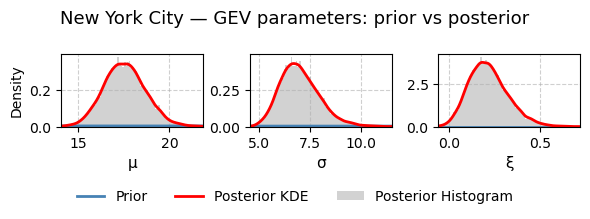

In [4]:
from scipy.stats import norm as norm 
from scipy.stats import gaussian_kde

# --- load your saved posterior samples ---
sample_1h_aorc = np.load(r"D:\BMM-IDF4Drainage_data_results\Sample\all_samples_and_p_bayes_1h_AORC.npz")
save_samples_1h = sample_1h_aorc["saved_samples_1h_AORC"]

# pick a city index
i = 29  # <-- change this to the city you want

# map your saved arrays to parameter names (from your code’s assignment order)
post_xi    = save_samples_1h[i, 0, :]   # ξ (shape)
post_mu    = save_samples_1h[i, 1, :]   # μ (location)
post_sigma = save_samples_1h[i, 2, :]   # σ (scale)

# --- priors exactly as in your model code ---
prior_mu    = norm(loc=0.1,  scale=100.0)
prior_sigma = norm(loc=0.1,  scale=100.0)
prior_xi    = norm(loc=0.15, scale=100.0)

priors = {"μ": prior_mu, "σ": prior_sigma, "ξ": prior_xi}
posts  = {"μ": post_mu,   "σ": post_sigma, "ξ": post_xi}

# --- Plot priors vs posteriors for all three parameters ---
fig, axes = plt.subplots(1, 3, figsize=(6, 1.8))

for idx, (ax, name) in enumerate(zip(axes, ["μ", "σ", "ξ"])):
    samples = posts[name]
    prior   = priors[name]

    # --- posterior x-range ---
    ql, qh = np.percentile(samples, [0.05, 99.95])
    x_min = ql
    x_max = qh
    if name == "σ":
        x_min = max(x_min, 1e-6)

    # --- full prior range ---
    pm = prior.mean()
    ps = prior.std()
    x_prior = np.linspace(pm - 4*ps, pm + 4*ps, 1000)

    # --- posterior KDE range ---
    x_post = np.linspace(x_min, x_max, 500)

    # posterior histogram
    sns.histplot(
        samples,
        bins=100,
        stat="density",
        color="gray",
        alpha=0.35,
        edgecolor=None,
        ax=ax,
        label="Posterior Histogram" if name == "μ" else None
    )

    # prior pdf
    ax.plot(
        x_prior, prior.pdf(x_prior),
        lw=2, color="steelblue",
        label="Prior" if name == "μ" else None
    )

    # posterior KDE
    kde = gaussian_kde(samples)
    ax.plot(
        x_post, kde(x_post),
        lw=2, color="red",
        label="Posterior KDE" if name == "μ" else None
    )

    # apply posterior x-limits
    ax.set_xlim(x_min, x_max)

    # ----- x-label on all -----
    ax.set_xlabel(name, fontsize=11)

    # ----- y-label ONLY for μ (first axis) -----
    if idx != 0:
        ax.set_ylabel("", fontsize=11)

    ax.grid(True, linestyle="--", alpha=0.6)
    ax.set_ylim(0,)


# ---- one shared legend below all subplots ----
fig.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, +0.05),
    ncol=3,
    frameon=False,
    fontsize=10
)

fig.suptitle(f"{cities[i]} — GEV parameters: prior vs posterior", fontsize=13, y=0.98)
fig.tight_layout()
plt.savefig(fr'D:\BMM-IDF4Drainage_data_results\Figure\{cities[i]}_param_prior_posterior.png', dpi=300, bbox_inches="tight")
plt.show()


## All cities

Saved: D:\BMM-IDF4Drainage_data_results\Figure\ALL_CITIES_prior_posterior_GRID.png


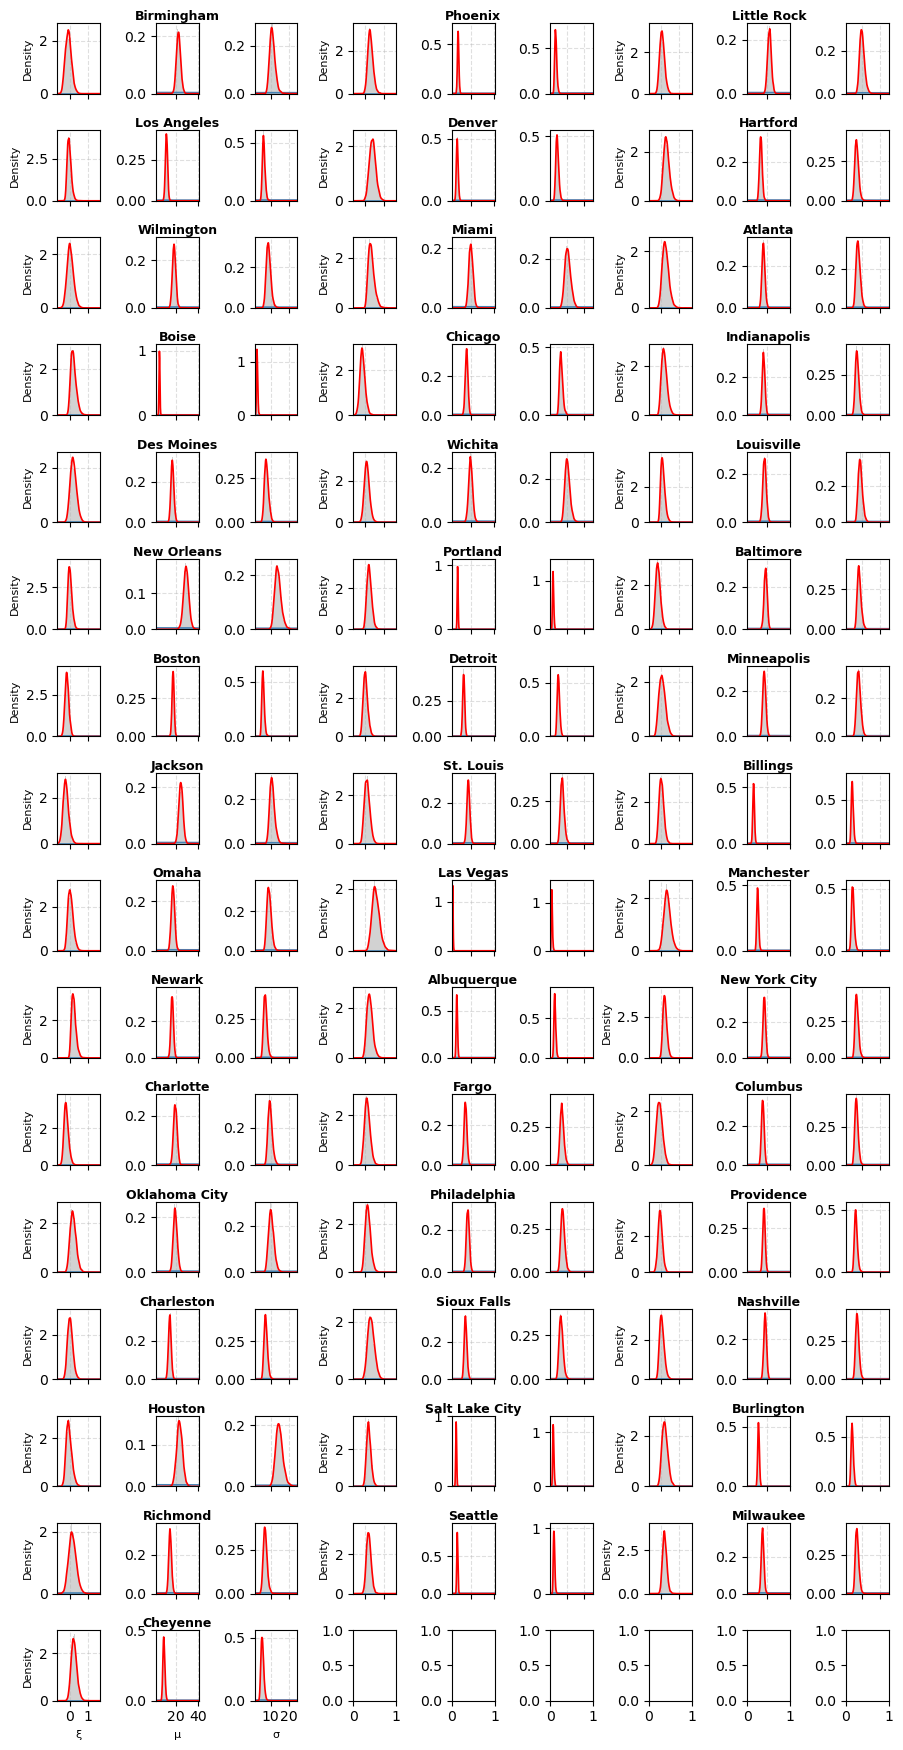

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm, gaussian_kde
import seaborn as sns
import math

# --------------------------------------------------------
# Load samples
# --------------------------------------------------------
data = np.load(r"D:\BMM-IDF4Drainage_data_results\Sample\all_samples_and_p_bayes_1h_AORC.npz")
save_samples_1h = data["saved_samples_1h_AORC"]

param_names = ["ξ", "μ", "σ"]

prior_mu    = norm(loc=0.1,  scale=100.0)
prior_sigma = norm(loc=0.1,  scale=100.0)
prior_xi    = norm(loc=0.15, scale=100.0)
priors = {"μ": prior_mu, "σ": prior_sigma, "ξ": prior_xi}

# --------------------------------------------------------
# Compute global x-limits (Option A)
# --------------------------------------------------------
global_limits = {}

for j, pname in enumerate(param_names):
    all_samples = save_samples_1h[:, j, :].reshape(-1)
    global_limits[pname] = (np.min(all_samples), np.max(all_samples))

# --------------------------------------------------------
# Layout
# --------------------------------------------------------
num_cities = len(cities)
num_rows = math.ceil(num_cities / 3)

fig, axes = plt.subplots(
    num_rows, 9,
    figsize=(9, 1.1 * num_rows),
    squeeze=False
)

# Reduce spacing
plt.subplots_adjust(
    wspace=0,   # horizontal space
    hspace=0    # vertical space
)

# --------------------------------------------------------
# Helper function
# --------------------------------------------------------
def plot_city(city_idx, col_block_start, row_idx, last_row):
    city_name = cities[city_idx]

    post_xi    = save_samples_1h[city_idx, 0, :]
    post_mu    = save_samples_1h[city_idx, 1, :]
    post_sigma = save_samples_1h[city_idx, 2, :]
    posts = {"μ": post_mu, "σ": post_sigma, "ξ": post_xi}

    # Put city name closer & smaller
    mid_col = col_block_start + 1
    axes[row_idx, mid_col].set_title(
        city_name,
        fontsize=9,
        pad=1,
        fontweight='bold'
    )

    for j, pname in enumerate(param_names):
        ax = axes[row_idx, col_block_start + j]
        samples = posts[pname]
        prior   = priors[pname]

        x_min, x_max = global_limits[pname]

        # Histogram
        sns.histplot(
            samples, bins=200, stat="density",
            color="gray", alpha=0.35, edgecolor=None, ax=ax
        )
        ax.set_anchor('C')              # center axis content
        ax.margins(x=0, y=0)            # remove internal margins

        # y-labels only on left city block
        global_col = col_block_start + j
        if global_col % 3 != 0:
            ax.set_ylabel("")
        else:
            ax.set_ylabel("Density", fontsize=8)

        # Prior
        pm, ps = prior.mean(), prior.std()
        x_prior = np.linspace(x_min, x_max, 300)
        ax.plot(x_prior, prior.pdf(x_prior), lw=1.2, color="steelblue")

        # KDE
        try:
            kde = gaussian_kde(samples)
            ax.plot(x_prior, kde(x_prior), lw=1.2, color="red")
        except:
            pass

        ax.set_xlim(x_min, x_max)

        # Show x-axis label only on last row
        if last_row:
            ax.set_xlabel(pname, fontsize=8)
        else:
            ax.set_xlabel("")
            ax.set_xticklabels([])

        ax.grid(True, linestyle="--", alpha=0.4)
        ax.set_ylim(bottom=0)

# --------------------------------------------------------
# Fill rows
# --------------------------------------------------------
city_counter = 0
for r in range(num_rows):

    last_row = (r == num_rows - 1)

    # City block 1 → columns 0,1,2
    if city_counter < num_cities:
        plot_city(city_counter, col_block_start=0, row_idx=r, last_row=last_row)
        city_counter += 1

    # City block 2 → columns 3,4,5
    if city_counter < num_cities:
        plot_city(city_counter, col_block_start=3, row_idx=r, last_row=last_row)
        city_counter += 1

    # City block 3 → columns 6,7,8
    if city_counter < num_cities:
        plot_city(city_counter, col_block_start=6, row_idx=r, last_row=last_row)
        city_counter += 1

# Save figure
plt.tight_layout()
out = r"D:\BMM-IDF4Drainage_data_results\Figure\ALL_CITIES_prior_posterior_GRID.png"
plt.savefig(out, dpi=300, bbox_inches="tight")
print("Saved:", out)


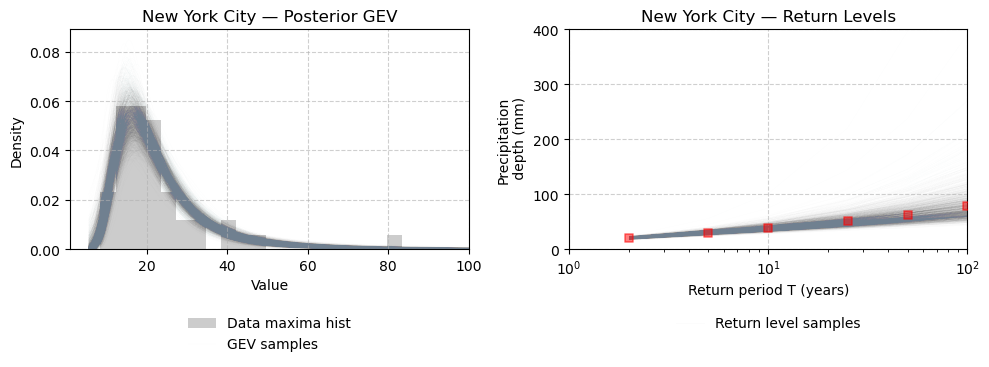

In [53]:
# --- pull posterior samples for city i (already defined above) ---
xi_s    = post_xi
mu_s    = post_mu
sigma_s = post_sigma

# subset for plotting to keep it snappy
K = min(2000, xi_s.size)
rng = np.random.default_rng(12345)
idx = rng.choice(xi_s.size, size=K, replace=False)

xi_sub    = xi_s[idx]
mu_sub    = mu_s[idx]
sigma_sub = sigma_s[idx]

# --- Posterior predictive draws to set plotting range + show histogram ---
x_pred = genextreme.rvs(c=-xi_sub, loc=mu_sub, scale=sigma_sub, random_state=rng)

# x-grid covering the central mass of the predictive
x_lo, x_hi = np.nanpercentile(x_pred, [0.005, 99.5])
x = np.linspace(x_lo, x_hi, 500)

# evaluate pdf for each posterior draw on the x-grid
pdf_stack = np.empty((K, x.size))
for j in range(K):
    pdf_stack[j, :] = genextreme.pdf(x, c=-xi_sub[j], loc=mu_sub[j], scale=sigma_sub[j])


# --- Bring in the city’s data (1h) to overlay histogram ---
data1 = np.array(dataframes.get(cities[i])["1h"])

# --- Compute return-levels for each posterior draw ---
T = np.array([2, 5, 10, 25, 50, 100])
p = 1 - 1 / T

q_stack = np.empty((K, T.size))
for j in range(K):
    q_stack[j, :] = genextreme.ppf(p, c=-xi_sub[j], loc=mu_sub[j], scale=sigma_sub[j])

q_mean = np.nanmean(q_stack,  axis=0)           # <-- predictive mean (return levels)
q_lo   = np.nanpercentile(q_stack, 2.5, axis=0)
q_hi   = np.nanpercentile(q_stack, 97.5, axis=0)

# --- Combined figure: two panels in one row ---
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plt.subplots_adjust(wspace=0.3)

# ===== Left panel: Posterior GEV PDF =====
ax = axes[0]
ax.hist(data1, bins=20, density=True,color='black', alpha=0.2, label="Data maxima hist")
df = pd.read_csv('D:\BMM-IDF4Drainage_data_results\Percentile\percentile_table_1h_AORC.csv')

# plot each sampled GEV curve with low alpha (gray)
for j in range(K):
    if j == 0:
        ax.plot(x, pdf_stack[j, :], color='slategray', alpha=0.02, lw=0.2, label="GEV samples", zorder=1)
    else:
        ax.plot(x, pdf_stack[j, :], color='slategray', alpha=0.02, lw=0.2, zorder=1)

# credible band and summary curves



df = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\percentile_table_1h_AORC.csv')

# columns in the CSV are strings like "50","80",...
perc_cols = ["50", "80", "90", "96", "98", "99"]
T_perc    = np.array([2, 5, 10, 25, 50, 100], dtype=float)  # mapping: T = 1/(1-p)

# pick the row for the current city (using your existing `cities[i]`)
row = df.loc[df["City"] == cities[i]].iloc[0]
y_perc = row[perc_cols].to_numpy(dtype=float)


ax.set_xlabel("Value")
ax.set_ylabel("Density")
ax.set_title(f"{cities[i]} — Posterior GEV")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlim(0, )

ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=1,
    frameon=False,
)
ax.set_xlim(1, 100)

# ===== Right panel: Return-Level plot =====
ax = axes[1]

# plot each sampled percentile curve in light gray
for j in range(K):
    if j==0:
        ax.semilogx(T, q_stack[j, :], color='slategray', alpha=0.02,label="Return level samples", lw=0.8, zorder=1)
    else:
        ax.semilogx(T, q_stack[j, :], color='slategray', alpha=0.02, lw=0.2, zorder=1)
ax.scatter(T_perc, y_perc, marker='s', linestyle='-', lw=1.2,color='red', alpha=0.5,
             zorder=3)
# credible band + summary curves

ax.set_xlabel("Return period T (years)")
ax.set_xlim(1, 100)
ax.set_ylim(0, 400)
ax.set_ylabel("Precipitation\n depth (mm)")
ax.set_title(f"{cities[i]} — Return Levels")
ax.grid(True, linestyle="--", alpha=0.6)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.5, -0.25),
    ncol=1,
    frameon=False,
)

plt.tight_layout()
plt.savefig(fr'D:\BMM-IDF4Drainage_data_results\Figure\{cities[i]}_return_level.png', dpi=300, bbox_inches="tight")
plt.show()

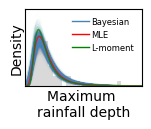

Saved to: D:\BMM-IDF4Drainage_data_results\Figure\New York City_posterior_GEV_leftpanel.png


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.stats import genextreme

# ==========================================================
# Load parameters (MLE + L-Moment)
# ==========================================================
mle_params = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\gev_params_1h_mle_AORC.csv')
mom_params = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_AORC_MOM.csv')

# posterior samples
sample_1h_aorc = np.load(r"D:\BMM-IDF4Drainage_data_results\Sample\all_samples_and_p_bayes_1h_AORC.npz")
save_samples_1h = sample_1h_aorc["saved_samples_1h_AORC"]

# pick city
i = 29
city_name = cities[i]

# posterior arrays
xi_s    = save_samples_1h[i, 0, :]
mu_s    = save_samples_1h[i, 1, :]
sigma_s = save_samples_1h[i, 2, :]

# subset for plotting
K = min(2000, xi_s.size)
rng = np.random.default_rng(12345)
idx = rng.choice(xi_s.size, size=K, replace=False)

xi_sub    = xi_s[idx]
mu_sub    = mu_s[idx]
sigma_sub = sigma_s[idx]

# predictive draws for x-range
x_pred = genextreme.rvs(c=-xi_sub, loc=mu_sub, scale=sigma_sub, random_state=rng)
x_lo, x_hi = np.nanpercentile(x_pred, [0.0005, 99.9995])
x = np.linspace(x_lo, x_hi, 500)

# posterior stack
pdf_stack = np.empty((K, x.size))
for j in range(K):
    pdf_stack[j, :] = genextreme.pdf(x, c=-xi_sub[j], loc=mu_sub[j], scale=sigma_sub[j])

# data
data1 = np.array(dataframes.get(city_name)["1h"])

# ==========================================================
# MLE
# ==========================================================
row_mle = mle_params.loc[mle_params['City'] == city_name].iloc[0]
c_mle    = float(row_mle['shape(c)'])
loc_mle  = float(row_mle['loc'])
scale_mle= float(row_mle['scale'])
pdf_mle  = genextreme.pdf(x, c=c_mle, loc=loc_mle, scale=scale_mle)

# ==========================================================
# L-moment
# ==========================================================
row_mom = mom_params.loc[mom_params['City'] == city_name].iloc[0]
c_mom    = float(row_mom['shape(c)'])
loc_mom  = float(row_mom['loc'])
scale_mom= float(row_mom['scale'])
pdf_mom  = genextreme.pdf(x, c=c_mom, loc=loc_mom, scale=scale_mom)

# ==========================================================
# PLOT
# ==========================================================
fig, ax = plt.subplots(figsize=(1.5, 1))

# histogram
ax.hist(data1, bins=20, density=True,
        color='black', alpha=0.15, linewidth=0)

# posterior GEV stack (Bayesian)
for j in range(K):
    ax.plot(
        x, pdf_stack[j, :],
        color="steelblue",
        alpha=0.06,
        linewidth=0.1,
        zorder=1
    )

# MLE pdf
ax.plot(x, pdf_mle, lw=1.0, color='red', alpha=0.7, label="MLE", zorder=4)

# L-moment pdf
ax.plot(x, pdf_mom, lw=1.0, color='green', alpha=0.7, label="L-moment", zorder=5)

# -----------------------
# Legend (with Bayesian)
# -----------------------
legend_handles = [
    Line2D([0], [0], color="steelblue", linewidth=1.0, label="Bayesian"),
    Line2D([0], [0], color="red", linewidth=1.0, label="MLE"),
    Line2D([0], [0], color="green", linewidth=1.0, label="L-moment"),
]

ax.legend(
    handles=legend_handles,
    loc="upper right",
    frameon=False,
    fontsize=6,
    handlelength=2.0,
    handletextpad=0.3
)

# axis formatting
ax.set_xlabel("Maximum \nrainfall depth", labelpad=2)
ax.set_ylabel("Density", labelpad=1)
ax.set_xlim(5, 100)
ax.set_ylim(bottom=0)

ax.set_xticks([])
ax.set_yticks([])

ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.4)

#ax.set_title(f"{city_name} — Posterior GEV", fontsize=8, pad=2)

plt.tight_layout(pad=200)
plt.show()

# save
save_path = fr"D:\BMM-IDF4Drainage_data_results\Figure\{city_name}_posterior_GEV_leftpanel.png"
fig.savefig(save_path, dpi=500, bbox_inches="tight")
print("Saved to:", save_path)

plt.close(fig)


In [49]:
# ================= MLE =================
city_name = cities[i]

row_mle = mle_params.loc[mle_params['City'] == city_name].iloc[0]

c_mle     = float(row_mle['shape(c)'])
loc_mle   = float(row_mle['loc'])
scale_mle = float(row_mle['scale'])

# MLE return levels
q_mle = genextreme.ppf(p, c=c_mle, loc=loc_mle, scale=scale_mle)

# ================= MOM =================
row_mom = mom_params.loc[mom_params['City'] == city_name].iloc[0]

c_mom     = float(row_mom['shape(c)'])
loc_mom   = float(row_mom['loc'])
scale_mom = float(row_mom['scale'])

# L-moment return levels
q_mom = genextreme.ppf(p, c=c_mom, loc=loc_mom, scale=scale_mom)


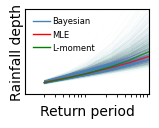

Right-panel plot saved to: D:\BMM-IDF4Drainage_data_results\Figure\New York City_return_levels_rightpanel.png


In [65]:
# ======================== RIGHT PANEL (Styled & Saved) ========================
from matplotlib.lines import Line2D

fig, ax = plt.subplots(figsize=(1.6, 1.1))

# --------------------------------------------------------------
# 1) Bayesian posterior samples (stacked faint curves)
# --------------------------------------------------------------
for j in range(K):
    ax.semilogx(
        T, q_stack[j, :],
        color="steelblue",
        alpha=0.06,
        linewidth=0.1,
        zorder=1
    )

# --------------------------------------------------------------
# 2) MLE return-level curve
# --------------------------------------------------------------
ax.semilogx(
    T, q_mle,
    lw=1.0, color='red', alpha=0.7,
    zorder=4
)

# --------------------------------------------------------------
# 3) L-moment return-level curve
# --------------------------------------------------------------
ax.semilogx(
    T, q_mom,
    lw=1.0, color='green', alpha=0.7,
    zorder=5
)



# --------------------------------------------------------------
# Axis formatting (minimal style like Left Panel)
# --------------------------------------------------------------
ax.set_xlabel("Return period", labelpad=2)
ax.set_ylabel("Rainfall depth", labelpad=1)

ax.set_xlim(1, 100)
ax.set_ylim(0, 150)

ax.set_xticks([])
ax.set_yticks([])

ax.grid(True, linestyle="--", linewidth=0.3, alpha=0.4)

#ax.set_title(f"{cities[i]} — Return Levels", fontsize=8, pad=2)

# --------------------------------------------------------------
# Legend (Bayesian / MLE / L-moment)
# --------------------------------------------------------------
legend_handles = [
    Line2D([0], [0], color="steelblue", linewidth=1.0, label="Bayesian"),
    Line2D([0], [0], color="red",       linewidth=1.0, label="MLE"),
    Line2D([0], [0], color="green",     linewidth=1.0, label="L-moment"),
]

ax.legend(
    handles=legend_handles,
    loc="upper left",
    frameon=False,
    fontsize=6,
    handlelength=2.0,
    handletextpad=0.3
)

# --------------------------------------------------------------
# SHOW + SAVE ALWAYS
# --------------------------------------------------------------
plt.tight_layout(pad=200)

save_path = fr"D:\BMM-IDF4Drainage_data_results\Figure\{cities[i]}_return_levels_rightpanel.png"

plt.savefig(save_path, dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

print("Right-panel plot saved to:", save_path)


# Animation

In [44]:
def pipe_sizing(depth, duration):
    """
    Calculates the required pipe diameter (D) given rainfall depth and duration
    using the Rational Method and Manning's formula.

    Parameters
    ----------
    depth : float
        Rainfall depth (mm)
    duration : float
        Duration (hr)
    """

    # rainfall intensity (mm/hr)
    I = depth / duration

    # drainage area (ha)
    if duration == 1:
        A = 10
    elif duration == 24:
        A = 40
    else:
        raise ValueError("Duration must be either 1 or 24 hours.")

    # discharge (m³/s)
    C = 0.65
    Q = 0.00278 * C * I * A

    # define Manning's and solve for D with S = 0.005, n = 0.013 initial guess 0.6 m 
    n = 0.013
    S = 0.005

    def func(D):
        return (0.31 / n) * D ** (8/3) * S ** 0.5 - Q

    D_initial = 0.6
    D_solution = fsolve(func, D_initial)[0]
    
    # Round up to nearest standard pipe size (mm)
    standard_sizes = np.array([450, 525, 600, 675, 750, 900, 1050,1200, 1350, 1500])  # mm
    D_mm = D_solution * 1000  # to mm
    D_rounded = standard_sizes[standard_sizes >= D_mm].min(initial=standard_sizes[-1])

    return  int(D_rounded)



In [105]:
# -*- coding: utf-8 -*-
# Posterior return levels animation: Bayesian (empirical percentiles) vs MLE & L-moments
# Uses 1000 posterior-predictive draws per parameter sample

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import genextreme
from matplotlib.collections import LineCollection
from matplotlib.animation import FuncAnimation, PillowWriter

# -------------------- INPUTS / CITY --------------------
# Assumes you already have: `cities`, `post_xi`, `post_mu`, `post_sigma`
#   - cities: list/array of city names
#   - post_xi, post_mu, post_sigma: posterior samples (1D arrays, same length)
city_idx = 8
city_name = cities[city_idx]
plt.rcParams["font.size"] = 15
# posterior samples (arrays shaped [Nsamples])
xi_s    = post_xi
mu_s    = post_mu
sigma_s = post_sigma

# -------------------- TUNABLES --------------------
STEP = 50 * 4              # animate every Nth posterior draw
TOTAL_SECONDS = 10
FIGSIZE = (6, 6)
LW_BG = 0.8                # gray background curve width
ALPHA_BG = 0.005           # gray background alpha
EMP_COLOR = "blue"           # blue for empirical percentiles
MS = 7                     # marker size for blue points
LW_PCTL = 0                # 0 => markers only (no connecting line)
MLE_COLOR = "red"
MOM_COLOR = "green"
LW_REF = 1.8
ALPHA_REF = 0.7
N_SIM = 1000               # NEW: number of posterior-predictive draws per parameter sample

# Optional: set to an integer to randomly thin the posterior for speed (e.g., 5000)
# Set to None to use all samples.
SUBSAMPLE_K = None

# -------------------- LOAD MLE / MOM --------------------
mle_params = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\gev_params_1h_mle_AORC.csv')
mom_params = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_AORC_MOM.csv')

row_mle = mle_params.loc[mle_params['City'] == city_name].iloc[0]
c_mle     = float(row_mle['shape(c)'])
loc_mle   = float(row_mle['loc'])
scale_mle = float(row_mle['scale'])

row_mom = mom_params.loc[mom_params['City'] == city_name].iloc[0]
c_mom     = float(row_mom['shape(c)'])
loc_mom   = float(row_mom['loc'])
scale_mom = float(row_mom['scale'])

# -------------------- SUBSET POSTERIOR (optional) --------------------
rng = np.random.default_rng(12345)

K_full = xi_s.size
if SUBSAMPLE_K is not None and SUBSAMPLE_K < K_full:
    idx = rng.choice(K_full, size=SUBSAMPLE_K, replace=False)
else:
    idx = np.arange(K_full)

xi_sub    = xi_s[idx]
mu_sub    = mu_s[idx]
sigma_sub = sigma_s[idx]
K = xi_sub.size

# -------------------- RETURN PERIODS --------------------
T = np.array([2, 5, 10, 25, 50, 100, 200, 500, 1000], dtype=float)
p = 1 - 1.0 / T                   # probs for return-levels
pcts_levels = 100.0 * p           # percent values for np.percentile

# -------------------- PRECOMPUTE (speed) --------------------
# 1) Per-sample return-level curves (for gray background)
q_stack = np.empty((K, T.size))
for j in range(K):
    q_stack[j, :] = genextreme.ppf(p, c=-xi_sub[j], loc=mu_sub[j], scale=sigma_sub[j])

# 2) Posterior-predictive samples (N_SIM r.v.s per parameter draw) for empirical percentiles
#    Shape: (K, N_SIM). Use trailing axis for broadcasting clarity.
y_pred = genextreme.rvs(
    c=-xi_sub[:, None],
    loc=mu_sub[:, None],
    scale=sigma_sub[:, None],
    size=(K, N_SIM),
    random_state=12345
)
# If memory is tight, uncomment the next line:
# y_pred = y_pred.astype(np.float32, copy=False)

# 3) MLE & MOM return levels (static)
q_mle = genextreme.ppf(p, c=c_mle, loc=loc_mle, scale=scale_mle)
q_mom = genextreme.ppf(p, c=c_mom, loc=loc_mom, scale=scale_mom)

# -------------------- ANIMATION CLOCK --------------------
FPS = 20                 # choose the same FPS you want for both GIFs
DURATION = TOTAL_SECONDS
N_FRAMES = FPS * DURATION

frames = np.linspace(1, K, N_FRAMES, dtype=int)
fps = FPS

# -------------------- FIGURE --------------------
fig, ax = plt.subplots(1, 1, figsize=FIGSIZE)
ax.set_xscale("log")

# Gray background: per-sample return-level curves (accumulate over frames)
q_segments = np.stack([np.column_stack([T, q_stack[j, :]]) for j in range(K)], axis=0)
lc_bg = LineCollection([], linewidths=LW_BG, colors=(0.2, 0.2, 0.2, ALPHA_BG), zorder=1)
ax.add_collection(lc_bg)

# Static MLE & MOM overlays
(mle_line,) = ax.semilogx(
    T, q_mle, lw=LW_REF, marker='o', color=MLE_COLOR,
    alpha=ALPHA_REF, label='MLE',markersize=10, zorder=3
)
(mom_line,) = ax.semilogx(
    T, q_mom, lw=LW_REF, marker='^', color=MOM_COLOR,
    alpha=ALPHA_REF, label='L moments',markersize=10, zorder=3
)

# Blue empirical-percentile markers (from predictive samples up to n)
(emp_line,) = ax.semilogx(
    T, np.nan * np.ones_like(T),
    color=EMP_COLOR, marker="*", lw=LW_PCTL, markersize=10, zorder=4,
    label="Bayesian"
)

# Labels, limits, grid, title
ax.set_xlabel(f"Return period ($years$)", labelpad=1)
ax.set_ylabel(f"Precipitation depth ($mm$)", labelpad=1)
ax.set_title(f"{city_name} — Return Levels")
ax.grid(True, linestyle="--", alpha=0.6)
ax.set_xlim(1, 1000)
ymax_all = np.nanmax([np.nanmax(q_stack), np.nanmax(q_mle), np.nanmax(q_mom)])
# ax.set_ylim(0, ymax_all * 1.1)   # automatic
ax.set_ylim(0, 350)                 # fixed, as in your snippet
ax.legend(frameon=False, loc="upper left")

# -------------------- ANIMATION FUNCS --------------------
def init():
    lc_bg.set_segments([])                  # start with no gray curves
    emp_line.set_data(T, np.nan * T)        # no blue points yet
    return (lc_bg, emp_line, mle_line, mom_line)

def update(n):
    # 1) Gray background curves up to n
    lc_bg.set_segments(q_segments[:n])

    # 2) Empirical percentiles from predictive samples up to n parameter draws
    #    Pool the first n rows (each has N_SIM samples) -> shape (n*N_SIM,)
    q_empirical = np.percentile(y_pred[:n, :].ravel(), pcts_levels)

    emp_line.set_data(T, q_empirical)
    return (lc_bg, emp_line, mle_line, mom_line)

ani = FuncAnimation(
    fig, update, init_func=init,
    frames=frames, interval=1000 / fps,
    blit=False, save_count=len(frames),
    cache_frame_data=False
)

# -------------------- SAVE --------------------
gif_path = rf"D:\BMM-IDF4Drainage_data_results\Animation\posterior_return_levels_empirical_{city_name}_with_MLE_MOM.gif"
ani.save(gif_path, writer=PillowWriter(fps=fps), savefig_kwargs={"facecolor": "white"})
plt.close(fig)
print(f"Saved: {gif_path}")


Saved: D:\BMM-IDF4Drainage_data_results\Animation\posterior_return_levels_empirical_Atlanta_with_MLE_MOM.gif


### Pipe sizing animation

In [104]:
# ---------------------------------------------------------
# ANIMATION OF PIPE DIAMETERS (2–1000 yr rainfall)
# Bayesian (empirical) + MLE + L-moments
# 3×3 grid, 3 circles per return period
# Continuous pipe sizes, global scale, true circles
# ---------------------------------------------------------

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.animation import FuncAnimation, PillowWriter
from scipy.optimize import fsolve

# =========================================================
# 1) Continuous pipe sizing function (NO rounding)
# =========================================================
def pipe_sizing_continuous(depth_mm, duration_h):
    """
    depth_mm : rainfall depth (mm)
    duration_h : 1 or 24 (hours)
    returns continuous pipe diameter in mm (no rounding to standard sizes)
    """
    I = depth_mm / duration_h  # mm/hr

    if duration_h == 1:
        A = 10.0
    elif duration_h == 24:
        A = 40.0
    else:
        raise ValueError("Duration must be 1 or 24 hours.")

    C = 0.65
    Q = 0.00278 * C * I * A  # m^3/s

    n = 0.013
    S = 0.005

    def func(D):
        # D in meters
        return (0.31 / n) * D ** (8.0 / 3.0) * S ** 0.5 - Q

    D_initial = 0.6  # m
    D_solution = fsolve(func, D_initial)[0]  # m

    return float(D_solution * 1000.0)  # mm (continuous)


# =========================================================
# 2) Return periods, MLE/MOM pipe sizes, Bayesian percentiles
# =========================================================
T = np.array([2, 5, 10, 25, 50, 100, 200, 500, 1000], dtype=float)
p = 1.0 - 1.0 / T
pcts_levels = 100.0 * p  # percent levels for empirical Bayesian

# q_mle, q_mom, y_pred, K, STEP, city_name must already exist

# Continuous MLE & L-moments pipe diameters for EACH return period (fixed in time)
D_mle_vec = np.array([pipe_sizing_continuous(q_mle[i], duration_h=1) for i in range(len(T))])
D_mom_vec = np.array([pipe_sizing_continuous(q_mom[i], duration_h=1) for i in range(len(T))])

# Approximate final Bayesian pipe sizes (using all posterior predictive draws)
q_emp_final = np.percentile(y_pred.ravel(), pcts_levels)
D_bayes_final_vec = np.array(
    [pipe_sizing_continuous(q_emp_final[i], duration_h=1) for i in range(len(T))]
)

# Global min/max for scaling across ALL methods & return periods
D_MIN = min(D_mle_vec.min(), D_mom_vec.min(), D_bayes_final_vec.min())
D_MAX = max(D_mle_vec.max(), D_mom_vec.max(), D_bayes_final_vec.max())


# =========================================================
# 3) Animation settings and figure
# =========================================================
# ---------- FIXED-DURATION ANIMATION CLOCK ----------
FPS = 20                   # pick your global fps
DURATION = 10              # seconds
N_FRAMES = FPS * DURATION  # total frames

frames = np.linspace(1, K, N_FRAMES, dtype=int)
fps = FPS

fig, ax = plt.subplots(figsize=(7, 7)) 
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])
ax.set_title(f"{city_name} — Pipe sizing for multiple return periods", fontsize=14)

# Force true circles (no ovals)
ax.set_aspect("equal", adjustable="box")

# --------------------------------------------------------
# REAL LEGEND WITH CIRCLE MARKERS (Bayesian, MLE, Lmom)
# --------------------------------------------------------
from matplotlib.lines import Line2D

blue  = (0.0, 0.0, 1.0, 0.8)
red   = (1.0, 0.0, 0.0, 0.8)
green = (0.0, 1.0, 0.0, 0.8)

legend_handles = [
    Line2D(
        [0], [0],
        color=blue,
        marker='o',
        markersize=12,
        linestyle='None',
        markerfacecolor='none',
        label="Bayesian"
    ),
    Line2D(
        [0], [0],
        color=red,
        marker='o',
        markersize=12,
        linestyle='None',
        markerfacecolor='none',
        label="MLE"
    ),
    Line2D(
        [0], [0],
        color=green,
        marker='o',
        markersize=12,
        linestyle='None',
        markerfacecolor='none',
        label="L-moments"
    )
]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.02),
    frameon=False,
    fontsize=12,
    ncol=3,             # <-- three columns
    columnspacing=1.5,  # spacing between columns
    handletextpad=0.4   # spacing between marker and label
)
# --------------------------------------------------------
# =========================================================
# 4) Map diameter (mm) → radius in axes units, global scale
# =========================================================
def pipe_radius_axes(d_mm, min_r=0.03, max_r=0.12):
    """
    Map diameter in mm to radius in axes coordinates, using global
    D_MIN and D_MAX for all methods and return periods.
    """
    x = (d_mm - D_MIN) / (D_MAX - D_MIN)
    x = np.clip(x, 0.0, 1.0)
    return min_r + x * (max_r - min_r)


# =========================================================
# 5) Define 3×3 grid centers in axes coords
# =========================================================
cols = np.array([0.18, 0.50, 0.82])
rows = np.array([0.95, 0.65, 0.30])

index_to_rc = [
    (0, 0), (0, 1), (0, 2),
    (1, 0), (1, 1), (1, 2),
    (2, 0), (2, 1), (2, 2),
]

centers = []
for i in range(len(T)):
    r, c = index_to_rc[i]
    centers.append((cols[c], rows[r]))
centers = np.array(centers)

# Label inside each circle: "X yr"
period_labels = []

for i in range(len(T)):
    cx, cy = centers[i]

    lab = ax.text(
        cx, cy,                      # centered in the circle
        f"{int(T[i])} yr",
        ha="center", va="center",
        fontsize=11,
        color="black",
        transform=ax.transAxes
    )
    period_labels.append(lab)

# Text for the frame index (optional)
frame_text = ax.text(
    0.5, 0.97, "",
    ha="center", va="center",
    fontsize=11,
    transform=ax.transAxes
)



# Dynamic text under each cell: pipe sizes (Bayes / MLE / Lmom)
offsets = {
    0: (0.10, 0.15, 0.20),   # top row: closer
    1: (0.12, 0.17, 0.22),   # middle row: medium
    2: (0.14, 0.19, 0.24)    # bottom row: current spacing
}
size_texts = []

for i in range(len(T)):
    cx, cy = centers[i]
    r, c = index_to_rc[i]  # row ID (0,1,2)

    off1, off2, off3 = offsets[r]

    txt_bayes = ax.text(
        cx, cy - off1,
        "",
        ha="center", va="center",
        fontsize=12,
        transform=ax.transAxes
    )

    txt_mle = ax.text(
        cx, cy - off2,
        "",
        ha="center", va="center",
        fontsize=12,
        transform=ax.transAxes
    )

    txt_lmom = ax.text(
        cx, cy - off3,
        "",
        ha="center", va="center",
        fontsize=12,
        transform=ax.transAxes
    )

    size_texts.append((txt_bayes, txt_mle, txt_lmom))


# =========================================================
# 6) Update function: 9 cells × 3 circles each
# =========================================================
def update(n):

    # Remove all old circles
    for obj in ax.findobj(match=Circle):
        obj.remove()

    # Empirical Bayesian depths (vector, length 9)
    q_emp_vec = np.percentile(y_pred[:n, :].ravel(), pcts_levels)

    # Colors with 50% alpha
    blue  = (0.0, 0.0, 1.0, 0.5)
    red   = (1.0, 0.0, 0.0, 0.5)
    green = (0.0, 1.0, 0.0, 0.5)

    for i in range(len(T)):
        cx, cy = centers[i]

        # Pipe sizes (mm)
        D_bayes = pipe_sizing_continuous(q_emp_vec[i], duration_h=1)
        D_mle   = D_mle_vec[i]
        D_mom   = D_mom_vec[i]

        # Radii in axes coordinates (global scale)
        r_bayes = pipe_radius_axes(D_bayes)
        r_mle   = pipe_radius_axes(D_mle)
        r_mom   = pipe_radius_axes(D_mom)

        # L-moments (green)
        mom_circle = Circle(
            (cx, cy), r_mom,
            fill=False, linewidth=2.5,
            edgecolor=green,
            transform=ax.transAxes
        )

        # MLE (red)
        mle_circle = Circle(
            (cx, cy), r_mle,
            fill=False, linewidth=2.5,
            edgecolor=red,
            transform=ax.transAxes
        )

        # Bayesian (blue, changes with n)
        bayes_circle = Circle(
            (cx, cy), r_bayes,
            fill=False, linewidth=2.5,
            edgecolor=blue,
            transform=ax.transAxes
        )

        ax.add_patch(mom_circle)
        ax.add_patch(mle_circle)
        ax.add_patch(bayes_circle)

        # Update text under this cell
        txt_bayes, txt_mle, txt_lmom = size_texts[i]

        txt_bayes.set_text(f"Bayes = {D_bayes:.0f} mm")
        txt_mle.set_text(  f"MLE   = {D_mle:.0f} mm")
        txt_lmom.set_text( f"Lmom  = {D_mom:.0f} mm")


    # With blit=False, returning nothing is fine,
    # but we return the texts for clarity.
    return size_texts


# =========================================================
# 7) Build and save animation
# =========================================================
ani = FuncAnimation(
    fig,
    update,
    frames=frames,
    interval=1000 / fps,
    blit=False
)

outpath = rf"D:\BMM-IDF4Drainage_data_results\Animation\pipe_sizes_grid_with_sizes_{city_name}.gif"
ani.save(outpath, writer=PillowWriter(fps=fps))
plt.close(fig)

print("Saved:", outpath)


Saved: D:\BMM-IDF4Drainage_data_results\Animation\pipe_sizes_grid_with_sizes_Atlanta.gif


# Save the return levels

In [133]:
# save return level results of 1-h duration
# Load the csv table as a DataFrame
df = pd.read_csv('D:\BMM-IDF4Drainage_data_results\Percentile\percentile_table_1h_AORC.csv')
df = df.round(1)
# Create a dictionary to map old column names to new column names
col_mapping = {'50': '2', '80': '5', '90': '10', '96': '25', '98': '50', '99': '100'}

df = df.rename(columns=col_mapping)
df = df.round(1)
# Save the renamed CSV file
df.to_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_1h_AORC_Bayesian.csv', index=False)
print(df)


              City     2     5    10    25     50    100
0       Birmingham  26.4  38.2  45.5  54.7   62.4   71.7
1          Phoenix   9.8  15.7  20.8  29.5   38.4   50.4
2      Little Rock  25.7  37.8  46.3  58.1   68.2   80.4
3      Los Angeles  14.0  20.8  25.3  31.1   35.6   40.7
4           Denver   9.3  17.3  25.1  39.8   56.5   81.5
5         Hartford  17.1  27.5  36.7  52.5   69.1   92.0
6       Wilmington  21.7  32.1  39.2  49.0   57.9   69.1
7            Miami  23.7  40.4  55.6  82.5  111.6  153.1
8          Atlanta  19.7  30.9  40.3  55.9   72.1   94.6
9            Boise   6.5   9.7  12.4  16.6   20.7   26.2
10         Chicago  18.2  25.2  29.2  33.8   37.2   41.1
11    Indianapolis  19.6  29.2  36.9  48.7   59.9   74.5
12      Des Moines  19.9  30.4  38.9  52.5   66.1   84.3
13         Wichita  23.2  36.3  45.8  59.4   71.5   86.2
14      Louisville  21.0  32.3  40.6  52.5   62.7   75.0
15     New Orleans  34.4  50.8  62.0  76.9   89.1  102.9
16        Portland   8.7  12.2 

# 24hr bayesian inference

In [ ]:
%%time
# Perform Bayesian Analysis for 24-h data sets
n_draws = 1000
sample_number = 3500
chain_n=4
# initialize the arrays
save_samples_24h = np.zeros([len(cities),3, sample_number*chain_n])
p_bayes_all_cities = np.zeros([len(cities), sample_number*chain_n,n_draws])
percentiles_all_cities = np.zeros([len(cities), 6])
percentiles = [50, 80, 90, 96, 98, 99]

for i in tqdm(range(len(cities)), desc="Processing Cities"):
    data2 = np.array(dataframes.get(cities[i])["24h"])
    #dataframes.get(cities[i]).dropna(subset=['24h'], inplace=True)
    with pm.Model() as model_gev:
        μ = pm.Normal("μ", mu=0.1, sigma=100)
        σ = pm.Normal("σ", mu=0.1, sigma=100)
        ξ = pm.Normal("ξ", mu=0.15, sigma=100)
    
        gev_24h = pm.DensityDist('gev', gev_logp, observed={'value': data2, 'μ': μ, 'σ': σ, 'ξ': ξ})
        step = pm.NUTS(target_accept=0.999,max_treedepth=15)
        trace_24h = pm.sample(sample_number, step=step, cores=4, chains=chain_n, tune=10_000, return_inferencedata=True, 
                            init="jitter+adapt_diag",
                            idata_kwargs={"density_dist_obs": False})
        
        #Save inferance accuracy results
        outdir = fr"D:\BMM-IDF4Drainage_data_results\Figure\Bayseian inference accuracy\AORC\24hr\{cities[i]}"
        os.makedirs(outdir, exist_ok=True)
        # pair plot
        ax1 =az.plot_pair(
            trace_24h,
            var_names=["μ", "σ", "ξ"],
            divergences=True,
            divergences_kwargs={"markersize": 3, "alpha": 0.6,"color": "red"},                # <-- highlights the divergent region(s)
            kind='hexbin',          # or "kde" if you prefer contours
            marginals=True,
            figsize=(6, 6) 
        )
        fig1 = ax1.ravel()[0].figure if hasattr(ax1, "ravel") else plt.gcf()
        figpath = os.path.join(outdir, f"{cities[i]}_pair.png")
        fig1.savefig(figpath, dpi=300, bbox_inches="tight")
        plt.close(fig1)
        # energy/BFMI issues that often accompany divergences
        ax2 = az.plot_energy(trace_24h, figsize=(4, 3))
        ax2.legend(fontsize=6, loc="upper left")
        fig2 = plt.gcf()
        figpath = os.path.join(outdir, f"{cities[i]}_energy_BFMI.png")
        fig2.savefig(figpath, dpi=300, bbox_inches="tight")
        plt.close(fig2)
        # Print numeric ranges of the divergent region vs non-divergent and save in a CSV
        post = trace_24h.posterior.stack(draws=("chain","draw"))
        div  = trace_24h.sample_stats.stack(draws=("chain","draw"))["diverging"].values.astype(bool)

        def summarize(var):
            vals_div    = post[var].values[div]
            vals_ok     = post[var].values[~div]
            return {
                "div_min":  np.nanmin(vals_div)  if vals_div.size else np.nan,
                "div_med":  np.nanmedian(vals_div) if vals_div.size else np.nan,
                "div_max":  np.nanmax(vals_div)  if vals_div.size else np.nan,
                "ok_min":   np.nanmin(vals_ok),
                "ok_med":   np.nanmedian(vals_ok),
                "ok_max":   np.nanmax(vals_ok),
            }
        summary_table = pd.DataFrame({v: summarize(v) for v in ["μ", "σ", "ξ"]}).T
        summary_table.index.name = "Variable"
        divergence_summary_path = os.path.join(outdir, f"{cities[i]}_divergence_summary.csv")
        summary_table.to_csv(divergence_summary_path, float_format="%.6f",encoding="utf-8-sig")
        # Rhat and save in a CSV
        rhat = az.rhat(trace_24h)
        rhat_dict = {var: float(rhat[var].values) for var in rhat.data_vars}
        rhat_table = pd.DataFrame.from_dict(rhat_dict, orient="index", columns=["Rhat"])
        rhat_table.index.name = "Variable"
        rhat_path = os.path.join(outdir, f"{cities[i]}_rhat.csv")
        rhat_table.to_csv(rhat_path, float_format="%.6f",encoding="utf-8-sig")

        # percentile computation

        stacked_24h = trace_24h.posterior.stack(draws=("chain", "draw"))
        
        shape_posterior1 = stacked_24h.ξ.values
        loc_posterior1 = stacked_24h.μ.values
        scale_posterior1 = stacked_24h.σ.values
        save_samples_24h[i, 0, :] = shape_posterior1   
        save_samples_24h[i, 1, :] = loc_posterior1 
        save_samples_24h[i, 2, :] = scale_posterior1 
        c     = (-save_samples_24h[i, 0, :])[:, None]                 
        loc   = ( save_samples_24h[i, 1, :])[:, None]                 
        scale = (save_samples_24h[i, 2, :])[:, None]
        
        # Draw 1000 samples for each of 3500*chain_n posterior parameter sets
        draws = genextreme.rvs(c=c, loc=loc, scale=scale,
                            size=(sample_number*chain_n, n_draws), random_state=12345)
        p_bayes_all_cities[i, :, :] = draws
        # Percentiles over all 3500*chain_n*n_draws samples for city i
        percentiles_all_cities[i, :] = np.percentile(draws.ravel(), percentiles)

np.savez(r"D:\BMM-IDF4Drainage_data_results\Sample\all_samples_and_p_bayes_24h_AORC_Bayes.npz", 
        saved_samples_24h_AORC_Bayes=save_samples_24h, 
         p_bayes_24h_AORC_Bayes=p_bayes_all_cities)
# save percentiles to a table
percentile_table = pd.DataFrame(percentiles_all_cities, columns=percentiles, index=cities)
percentile_table.index.name = 'City'
percentile_table.to_csv('D:\BMM-IDF4Drainage_data_results\Percentile\percentile_table_24h_AORC_Bayes.csv')


# Save

In [135]:
# save the return level estimates of 24-hour duration

# Load the csv table as a DataFrame
df = pd.read_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\percentile_table_24h_AORC_Bayes.csv')
# Create a dictionary to map old column names to new column names
col_mapping = {'50': '2', '80': '5', '90': '10', '96': '25', '98': '50', '99': '100'}

# Rename columns using the dictionary
df = df.rename(columns=col_mapping)
df = df.round(1)
# Save the renamed CSV file
df.to_csv(r'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_AORC_Bayes.csv', index=False)
print(df)


              City      2      5     10     25     50    100
0       Birmingham   79.6  110.8  133.3  164.7  191.4  222.7
1          Phoenix   25.0   38.0   48.5   64.9   80.5  100.3
2      Little Rock   78.3  109.1  134.9  177.3  220.3  278.4
3      Los Angeles   57.9   90.2  113.2  145.4  173.7  208.6
4           Denver   34.7   46.9   55.0   65.8   74.5   84.3
5         Hartford   66.9   86.4   99.9  118.1  133.2  150.5
6       Wilmington   64.0   88.8  109.3  142.4  175.2  218.6
7            Miami   78.4  120.3  159.8  230.3  305.2  408.3
8          Atlanta   68.5   91.7  109.8  137.7  164.5  199.6
9            Boise   21.8   28.7   33.3   39.2   44.0   49.3
10         Chicago   54.5   74.5   89.7  111.7  131.1  153.9
11    Indianapolis   56.6   74.7   87.4  104.9  119.7  137.1
12      Des Moines   52.8   66.8   77.7   94.2  109.4  128.2
13         Wichita   63.3   88.0  106.8  134.5  159.5  190.0
14      Louisville   65.2   91.5  109.6  134.0  154.7  179.0
15     New Orleans  105.


Constrained GEV MLE (SciPy parameterization):
  c (constrained to [-0.5, 0.5]) = 0.500000
  loc (μ)                         = 73.702841
  scale (σ)                       = 25.664412
  xi (ξ = -c)                     = -0.500000


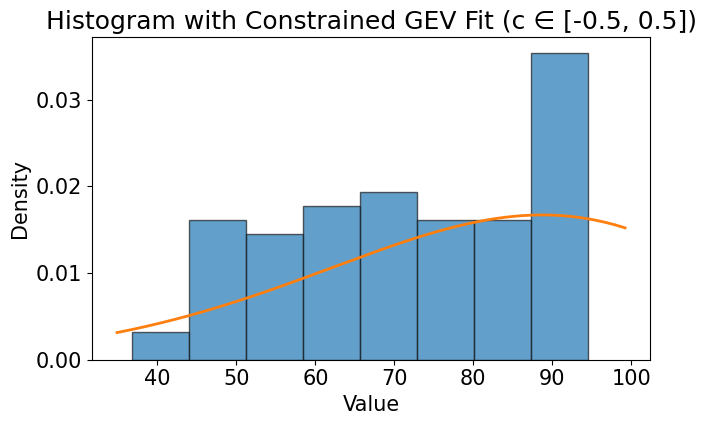

Figure saved as: hist_gev_fit_constrained.png


In [190]:
def neg_loglike(params, x):
    c, loc, log_scale = params
    scale = np.exp(log_scale)

    # Support check: 1 + c * (x - loc)/scale > 0 for all x
    # (When c ~ 0, genextreme handles the Gumbel limit internally.)
    t = 1.0 + c * (x - loc) / scale
    if np.any(t <= 0.0) or not np.isfinite(scale):
        return 1e50  # large penalty outside support

    ll = genextreme.logpdf(x, c, loc=loc, scale=scale)
    if not np.all(np.isfinite(ll)):
        return 1e50
    return -np.sum(ll)

# Initial guess: start from unconstrained fit, then clip c
try:
    c0_fit, loc0_fit, scale0_fit = genextreme.fit(data)
    c0 = np.clip(c0_fit, -0.5, 0.5)
    loc0 = float(loc0_fit)
    log_s0 = float(np.log(scale0_fit if scale0_fit > 0 else np.std(data)))
except Exception:
    # Fallback initials
    c0 = 0.0
    loc0 = float(np.median(data))
    log_s0 = float(np.log(np.std(data)))

x0 = np.array([c0, loc0, log_s0])

# Bounds: c in [-0.5, 0.5]; loc free (use a wide box); log_scale in [-20, 20] (~[2e-9, 4.8e8])
bounds = [(-0.5, 0.5), (min(data) - 1000, max(data) + 1000), (-20.0, 20.0)]

res = minimize(
    fun=neg_loglike,
    x0=x0,
    args=(data,),
    method="L-BFGS-B",
    bounds=bounds,
)

if not res.success:
    print("WARNING: Optimization did not fully converge:", res.message)

c_hat, loc_hat, log_s_hat = res.x
scale_hat = float(np.exp(log_s_hat))

# Convert to hydrology convention if desired: xi = -c
xi_hat = -c_hat
mu_hat = loc_hat
sigma_hat = scale_hat

print("\nConstrained GEV MLE (SciPy parameterization):")
print(f"  c (constrained to [-0.5, 0.5]) = {c_hat:.6f}")
print(f"  loc (μ)                         = {mu_hat:.6f}")
print(f"  scale (σ)                       = {sigma_hat:.6f}")
print(f"  xi (ξ = -c)                     = {xi_hat:.6f}")

# ----------------- Plot & Save --------------------
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(data, bins="auto", density=True, alpha=0.7, edgecolor="k")

x = np.linspace(min(data) * 0.95, max(data) * 1.05, 400)
pdf = genextreme.pdf(x, c_hat, loc=mu_hat, scale=sigma_hat)
ax.plot(x, pdf, linewidth=2)

ax.set_title("Histogram with Constrained GEV Fit (c ∈ [-0.5, 0.5])")
ax.set_xlabel("Value")
ax.set_ylabel("Density")

plt.tight_layout()
plt.savefig("hist_gev_fit_constrained.png", dpi=300)
plt.show()
print("Figure saved as: hist_gev_fit_constrained.png")

# 24hr bayesian inference SSP

In [ ]:
#for scen in ['126_2025_2064','126_2065_2100','370_2025_2064','370_2065_2100','585_2025_2064','585_2065_2100']:
for scen in ['585_2065_2100']:

#for scen in ['585_2025_2100']:

    # Perform Bayesian Analysis for 24-h CMIP6 
    n_draws = 1000
    sample_number = 3500
    chain_n=4
    # initialize the arrays
    save_samples_24h = np.zeros([len(cities),3, sample_number*chain_n])
    p_bayes_all_cities = np.zeros([len(cities), sample_number*chain_n,n_draws])
    percentiles_all_cities = np.zeros([len(cities), 6])
    percentiles = [50, 80, 90, 96, 98, 99]
    for i in tqdm(range(len(cities)), desc="Processing Cities"):
        try:      
            print(cities[i]) 
            data = np.array(dataframes_ssp.get(cities[i])[scen])
            data = data[~np.isnan(data)]
            with pm.Model() as model_gev:
                
                μ = pm.Normal("μ", mu=0.1, sigma=200)
                σ = pm.Normal("σ", mu=0.1, sigma=200)
                ξ = pm.Normal("ξ", mu=0.15, sigma=200)
                gev_24h = pm.DensityDist('gev', gev_logp, observed={'value': data, 'μ': μ, 'σ': σ, 'ξ': ξ})
                step = pm.NUTS(target_accept=0.999,max_treedepth=15)
                

                trace_24h = pm.sample(sample_number, step=step, cores=4, chains=chain_n, tune=10_000, return_inferencedata=True, 
                                      
                                    idata_kwargs={"density_dist_obs": False})

                #Save inferance accuracy results
                outdir = fr"D:\BMM-IDF4Drainage_data_results\Figure\Bayseian inference accuracy\CMIP6\24hr\{scen}\{cities[i]}"
                os.makedirs(outdir, exist_ok=True)
                # pair plot
                ax1 =az.plot_pair(
                    trace_24h,
                    var_names=["μ", "σ", "ξ"],
                    divergences=True,
                    divergences_kwargs={"markersize": 3, "alpha": 0.6,"color": "red"},            
                    kind='hexbin',         
                    marginals=True,
                    figsize=(6, 6) 
                )
                fig1 = ax1.ravel()[0].figure if hasattr(ax1, "ravel") else plt.gcf()
                figpath = os.path.join(outdir, f"{cities[i]}_{scen}_pair.png")
                fig1.savefig(figpath, dpi=300, bbox_inches="tight")
                plt.close(fig1)
                # energy/BFMI issues that often accompany divergences
                ax2 = az.plot_energy(trace_24h, figsize=(4, 3))
                ax2.legend(fontsize=6, loc="upper left")
                fig2 = plt.gcf()
                figpath = os.path.join(outdir, f"{cities[i]}_{scen}_energy_BFMI.png")
                fig2.savefig(figpath, dpi=300, bbox_inches="tight")
                plt.close(fig2)
                # Print numeric ranges of the divergent region vs non-divergent and save in a CSV
                post = trace_24h.posterior.stack(draws=("chain","draw"))
                div  = trace_24h.sample_stats.stack(draws=("chain","draw"))["diverging"].values.astype(bool)

                def summarize(var):
                    vals_div    = post[var].values[div]
                    vals_ok     = post[var].values[~div]
                    return {
                        "div_min":  np.nanmin(vals_div)  if vals_div.size else np.nan,
                        "div_med":  np.nanmedian(vals_div) if vals_div.size else np.nan,
                        "div_max":  np.nanmax(vals_div)  if vals_div.size else np.nan,
                        "ok_min":   np.nanmin(vals_ok),
                        "ok_med":   np.nanmedian(vals_ok),
                        "ok_max":   np.nanmax(vals_ok),
                    }
                summary_table = pd.DataFrame({v: summarize(v) for v in ["μ", "σ", "ξ"]}).T
                summary_table.index.name = "Variable"
                divergence_summary_path = os.path.join(outdir, f"{cities[i]}_{scen}_divergence_summary.csv")
                summary_table.to_csv(divergence_summary_path, float_format="%.6f",encoding="utf-8-sig")
                # Rhat and save in a CSV
                rhat = az.rhat(trace_24h)
                rhat_dict = {var: float(rhat[var].values) for var in rhat.data_vars}
                rhat_table = pd.DataFrame.from_dict(rhat_dict, orient="index", columns=["Rhat"])
                rhat_table.index.name = "Variable"
                rhat_path = os.path.join(outdir, f"{cities[i]}_{scen}_rhat.csv")
                rhat_table.to_csv(rhat_path, float_format="%.6f",encoding="utf-8-sig")

                # percentile computation

                stacked_24h = trace_24h.posterior.stack(draws=("chain", "draw"))
                
                shape_posterior1 = stacked_24h.ξ.values
                loc_posterior1 = stacked_24h.μ.values
                scale_posterior1 = stacked_24h.σ.values
                save_samples_24h[i, 0, :] = shape_posterior1   
                save_samples_24h[i, 1, :] = loc_posterior1 
                save_samples_24h[i, 2, :] = scale_posterior1 
                c     = (-save_samples_24h[i, 0, :])[:, None]                 
                loc   = ( save_samples_24h[i, 1, :])[:, None]                 
                scale = (save_samples_24h[i, 2, :])[:, None]
                
                # Draw 1000 samples for each of 3500*chain_n posterior parameter sets
                draws = genextreme.rvs(c=c, loc=loc, scale=scale,
                                    size=(sample_number*chain_n, n_draws), random_state=12345)
                p_bayes_all_cities[i, :, :] = draws
                # Percentiles over all 3500*chain_n*n_draws samples for city i
                percentiles_all_cities[i, :] = np.percentile(draws.ravel(), percentiles)

        except Exception:
            # if anything fails for this i, mark its bias as NaN and continue
            percentiles_all_cities[i, :] = np.nan
            p_bayes_all_cities[i, :, :] = np.nan
            save_samples_24h[i, 0, :]= np.nan
            continue

    np.savez(fr"D:\BMM-IDF4Drainage_data_results\Sample\all_samples_and_p_bayes_24h_CMIP6_Bayes_{scen}.npz", 
            saved_samples_24h_AORC_Bayes=save_samples_24h, 
            p_bayes_24h_AORC_Bayes=p_bayes_all_cities)
    # save percentiles to a table
    percentile_table = pd.DataFrame(percentiles_all_cities, columns=percentiles, index=cities)
    percentile_table.index.name = 'City'
    percentile_table.to_csv(fr'D:\BMM-IDF4Drainage_data_results\Percentile\percentile_table_24h_CMIP6_Bayes_{scen}.csv')


In [3]:
for scen in ['585_2065_2100']:
    # save the return levels
    # Load the csv table as a DataFrame
    df = pd.read_csv(fr'D:\BMM-IDF4Drainage_data_results\Percentile\percentile_table_24h_CMIP6_Bayes_{scen}.csv')
    # Create a dictionary to map old column names to new column names
    col_mapping = {'50': '2', '80': '5', '90': '10', '96': '25', '98': '50', '99': '100'}
    # Rename columns using the dictionary
    df = df.rename(columns=col_mapping)
    df = df.round(1)
    # Save the renamed CSV file
    df.to_csv(fr'D:\BMM-IDF4Drainage_data_results\Percentile\return_levels(mm)_24h_CMIP6_Bayes_{scen}.csv', index=False)
    #print(df)

In [ ]:
#Getting the current date and time
current_datetime = datetime.now()

# Printing the date and time
print("Date and Time of the Notebook Analysis:", current_datetime)

Date and Time of the Notebook Analysis: 2024-07-29 17:22:56.044172


In [ ]:
%load_ext watermark

# Print the Python version and some dependencies
%watermark -v -m -p numpy,pandas,matplotlib,pymc3,scipy,seaborn,arviz,os,theano,warnings,tqdm,watermark


Python implementation: CPython
Python version       : 3.9.19
IPython version      : 8.18.1

numpy     : 1.22.1
pandas    : 2.0.3
matplotlib: 3.8.4
pymc3     : 3.11.6
scipy     : 1.7.3
seaborn   : 0.13.2
arviz     : 0.12.1
os        : unknown
theano    : 1.1.2
warnings  : unknown
tqdm      : 4.66.4
watermark : 2.4.3

Compiler    : MSC v.1929 64 bit (AMD64)
OS          : Windows
Release     : 10
Machine     : AMD64
Processor   : Intel64 Family 6 Model 183 Stepping 1, GenuineIntel
CPU cores   : 24
Architecture: 64bit

